<a href="https://colab.research.google.com/github/harshpre5/Artificial_Neural_Networks_14444188_HS_6009CMD/blob/main/14444188_ANN_PART_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section:0** **Setup** **and** **datset**

## 1) Mounting Google Drive to access dataset

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) importing Libraries
following cell  loads all the required libraries for the notebook. To ensure the notebook runs correctly and to avoid redundant imports, all libraries have been consolidated in following cell.

In [71]:
import os # For directory operations and path handling.
import random # Used to set random seed for Python's built-in random operations.
import numpy as np # Used for numerical operations and setting numpy random seed.
import pandas as pd # Used to load the CSV file into a DataFrame.
import matplotlib.pyplot as plt # Used to set global plot parameters and create basic visualizations.
import seaborn as sns # Used to set global visualization themes and create statistical plots.
from sklearn.model_selection import train_test_split # Used to split the dataset into train, validation, and test sets.
from sklearn.preprocessing import StandardScaler, LabelEncoder # Used to standardize feature values and encode the target class.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # Used to evaluate classification model performance.
import tensorflow as tf # Used to set the TensorFlow random seed for reproducibility.
from tensorflow import keras # Used as the primary deep learning framework.
from tensorflow.keras import layers # Used to define the layers of the neural network architectures.
import math
from sklearn.decomposition import PCA
from tensorflow.keras import regularizers


# Section 1: Data Loading and Initial Inspection
This section sets up reproducible random seeds, configures global plotting preferences, and loads the dataset. It also performs basic data formatting, type casting, and quality checks.

In [72]:
# 1. Reproducibility
# Setting fixed seeds for all random number generators to ensure it runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Plot settings
# Establishing consistent global styling and dimensions for all visualizations.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


In [73]:
# 3. File path
file_path = "/content/drive/MyDrive/sensorless_drive_diagnosis_verified.csv"

# 4. Reading CSV
# Loading the dataset. low_memory=False prevents pandas from guessing datatypes in chunks
df = pd.read_csv(file_path, low_memory=False)

# 5. Standardising column names
df.columns = [str(c).strip() for c in df.columns]
df.columns = [f"Feature_{i}" for i in range(1, 49)] + ["Class"]

# 6. Converting feature columns to numeric
# Ensuring all features of data are strictly numeric.
# non-numeric anomalies (like strings or corrupted data) to become NaN (missing).
feature_cols = [f"Feature_{i}" for i in range(1, 49)]
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 7. Converting target/class column to integer
# Ensure the target variable is formatted as an integer.
df["Class"] = pd.to_numeric(df["Class"], errors="coerce").astype("Int64")

In [74]:
# 8. Basic inspection
# To verify the dataset loaded correctly and check for any issues.
print("\nDataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column (non-zero only):")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["Class"].value_counts().sort_index())

print("\nUnique classes:")
print(sorted(df["Class"].dropna().unique()))

# 9. Safety checks
# Hard enforcement of expected data conditions.
assert df.shape == (58508, 49), f"Unexpected shape: {df.shape}"
assert df[feature_cols].isnull().sum().sum() == 0, "There are missing feature values."
assert df["Class"].isnull().sum() == 0, "Class column has missing values."


Dataset shape: (58508, 49)

First 5 rows:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_40,Feature_41,Feature_42,Feature_43,Feature_44,Feature_45,Feature_46,Feature_47,Feature_48,Class
0,2.913200e-06,-5.247700e-06,0.000003,-6.056100e-06,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
1,-2.951700e-06,-3.184000e-06,-0.000016,-1.208400e-06,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
2,-1.322600e-06,8.820100e-06,-0.000016,-4.811100e-06,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
3,-6.836600e-08,5.666300e-07,-0.000026,-6.490100e-06,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1
4,-9.584900e-07,5.214300e-08,-0.000047,6.453700e-07,-2.304100e-06,0.000055,0.031154,0.031154,0.031201,-0.032789,...,-0.61124,5.8337,18.6970,-1.4956,-1.4956,-1.4956,-1.4973,-1.4972,-1.4973,1



Data types:
Feature_1     float64
Feature_2     float64
Feature_3     float64
Feature_4     float64
Feature_5     float64
Feature_6     float64
Feature_7     float64
Feature_8     float64
Feature_9     float64
Feature_10    float64
Feature_11    float64
Feature_12    float64
Feature_13    float64
Feature_14    float64
Feature_15    float64
Feature_16    float64
Feature_17    float64
Feature_18    float64
Feature_19    float64
Feature_20    float64
Feature_21    float64
Feature_22    float64
Feature_23    float64
Feature_24    float64
Feature_25    float64
Feature_26    float64
Feature_27    float64
Feature_28    float64
Feature_29    float64
Feature_30    float64
Feature_31    float64
Feature_32    float64
Feature_33    float64
Feature_34    float64
Feature_35    float64
Feature_36    float64
Feature_37    float64
Feature_38    float64
Feature_39    float64
Feature_40    float64
Feature_41    float64
Feature_42    float64
Feature_43    float64
Feature_44    float64
Feature_45    float

#Section 1 : Analysis
In this section, I loaded the Sensorless Drive Diagnosis dataset and did some initial inspection to confirm that the data had been imported correctly and was ready to use.First I set fixed random seeds to improve reproducibility and configured plotting settings so that later visualisations would be consistent throughout the notebook. I then loaded the dataset into a pandas DataFrame, standardised the column names into a clear format (Feature_1 to Feature_48 and Class), and converted the feature columns into numeric form while ensuring the target variable was stored as an integer. After this, I performed a series of basic checks including dataset shape, previewing the first few rows, reviewing data types, checking for missing values, checking for duplicate rows, and examining the class distribution and unique class labels. The results showed that the dataset contained 49 columns in total, with 48 input features and 1 target column, and that there were no missing values or duplicate rows. The class labels were valid and ranged from 1 to 11.

# Section 2: Data Audit and Quality Checks
This section conducts audit of the dataset's characteristics and quality. It calculates the statistics , checks for missing or duplicate values, identifies zero-variance features, and visualizes the class distribution and top feature variances to inform subsequent preprocessing steps.

In [75]:
# 1. Basic dataset summary
feature_cols = [f"Feature_{i}" for i in range(1, 49)]
print("Dataset shape:", df.shape)
print("Number of feature columns:", len(feature_cols))
print("Target column:", "Class")

# 2. Class distribution table
# Calculating the absolute count and the relative percentage for each class
# This will help to identify if the dataset is imbalanced (e.g., one class dominating others).
class_counts = df["Class"].value_counts().sort_index()
class_percent = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

print("\nClass distribution summary:")
display(class_summary)

# 3. Descriptive statistics for all features
desc_stats = df[feature_cols].describe().T
desc_stats["variance"] = df[feature_cols].var()
desc_stats["skewness"] = df[feature_cols].skew()

print("\nDescriptive statistics (first 10 features):")
display(desc_stats.head(10))

Dataset shape: (58508, 49)
Number of feature columns: 48
Target column: Class

Class distribution summary:


,Count,Percentage
Class,,
1,5318,9.0894
2,5319,9.0911
3,5319,9.0911
4,5319,9.0911
5,5319,9.0911
6,5319,9.0911
7,5319,9.0911
8,5319,9.0911
9,5319,9.0911



Descriptive statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max,variance,skewness
Feature_1,58508.0,-3.332904e-06,0.000072,-0.013721,-0.000007,-2.652700e-06,0.000002,0.005784,5.142534e-09,-139.596224
Feature_2,58508.0,1.439531e-06,0.000056,-0.005414,-0.000014,8.803500e-07,0.000019,0.004525,3.086331e-09,-12.209813
Feature_3,58508.0,1.412234e-06,0.000235,-0.013580,-0.000072,5.140150e-07,0.000075,0.005238,5.536745e-08,-3.231138
Feature_4,58508.0,-1.312798e-06,0.000063,-0.012787,-0.000005,-1.058800e-06,0.000004,0.001453,3.918294e-09,-175.777435
Feature_5,58508.0,1.351287e-06,0.000057,-0.008356,-0.000015,7.541400e-07,0.000019,0.000825,3.204683e-09,-62.548066
Feature_6,58508.0,-2.650900e-07,0.000226,-0.009741,-0.000074,-1.651450e-07,0.000071,0.002754,5.116311e-08,-2.436542
Feature_7,58508.0,1.914076e-03,0.036468,-0.139890,-0.019928,1.322600e-02,0.024768,0.069125,1.329893e-03,-1.468702
Feature_8,58508.0,1.912637e-03,0.036466,-0.135940,-0.019952,1.322950e-02,0.024775,0.069130,1.329739e-03,-1.468086
Feature_9,58508.0,1.911224e-03,0.036470,-0.130860,-0.019925,1.324650e-02,0.024775,0.069131,1.330053e-03,-1.466831
Feature_10,58508.0,-1.189695e-02,0.066483,-0.218640,-0.032141,-1.556600e-02,0.020615,0.352580,4.419968e-03,-1.017139


In [76]:
# 4. Variance checks
# Sorting features by variance to see which ones fluctuate the most vs. least.
variance_series = df[feature_cols].var().sort_values(ascending=False)
zero_variance_features = variance_series[variance_series == 0].index.tolist()

print("\nNumber of zero-variance features:", len(zero_variance_features))
print("Zero-variance features:", zero_variance_features if zero_variance_features else "None")

print("\nTop 10 highest-variance features:")
display(variance_series.head(10).to_frame("Variance"))

print("\nTop 10 lowest-variance features:")
display(variance_series.tail(10).to_frame("Variance"))

# 5. Numerical sanity checks
# Final boolean flags to confirm the data is "clean" before it hits a visualization or model.
print("\nAny missing feature values?:", df[feature_cols].isnull().sum().sum() > 0)
print("Any missing class values?:", df["Class"].isnull().sum() > 0)
print("Any duplicate rows?:", df.duplicated().sum() > 0)


Number of zero-variance features: 0
Zero-variance features: None

Top 10 highest-variance features:


,Variance
Feature_40,625.947447
Feature_37,415.997997
Feature_41,155.049192
Feature_38,149.838732
Feature_39,47.573479
Feature_42,43.112463
Feature_27,0.763691
Feature_30,0.737492
Feature_26,0.606563
Feature_29,0.582668



Top 10 lowest-variance features:


,Variance
Feature_13,1.038878e-06
Feature_16,9.018219e-07
Feature_14,4.449695e-07
Feature_17,4.308320e-07
Feature_3,5.536745e-08
Feature_6,5.116311e-08
Feature_1,5.142534e-09
Feature_4,3.918294e-09
Feature_5,3.204683e-09
Feature_2,3.086331e-09



Any missing feature values?: False
Any missing class values?: False
Any duplicate rows?: False


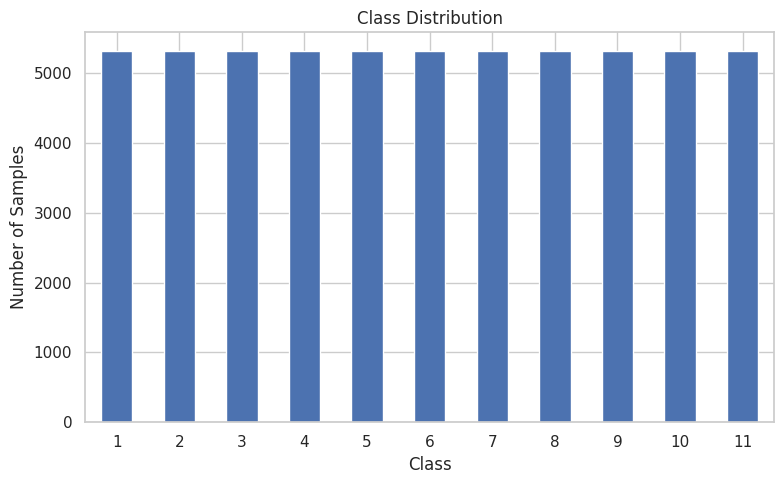

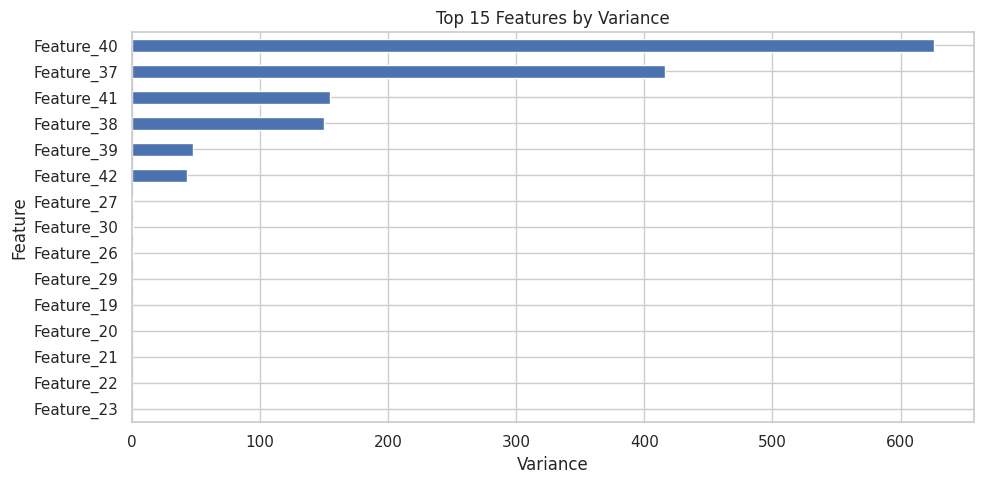


Audit summary:
rows: 58508
columns: 49
num_features: 48
num_classes: 11
missing_values_total: 0
duplicate_rows: 0
zero_variance_features: 0


In [77]:
# 6. Plot 1: Class Distribution
# Visualizing class counts to spot potential bias in the training data.
plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Plot 2: Top 15 Feature Variances
# Horizontal bar chart showing which 15 features have the highest spread.
plt.figure(figsize=(10,5))
variance_series.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features by Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 8. audit summary
# Creating a dictionary for a final 'health report' of the dataset.
audit_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "num_features": len(feature_cols),
    "num_classes": df["Class"].nunique(),
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "zero_variance_features": len(zero_variance_features)
}

print("\nAudit summary:")
for k, v in audit_summary.items():
    print(f"{k}: {v}")

# Section 2: Analysis
In this section, I did  some audit checks of the dataset to better understand its structure and behaviour before preprocessing. I began by summarising the dataset dimensions again and then created a class distribution table showing both the count and percentage of each class to assess whether the dataset was balanced. After that, I generated descriptive statistics for all feature columns, including measures such as mean, standard deviation, variance, and skewness, in order to understand the numerical spread and distribution of the features. I also ranked features by variance to identify which variables changed the most and which changed the least, and checked whether any features had zero variance. Finally, I ran additional sanity checks for missing values, missing class labels, and duplicate rows, and visualised the class distribution and the top 15 features by variance. The results showed that the dataset was essentially balanced across the 11 classes, contained no missing values, no duplicate rows, and no zero-variance features. The variance analysis also showed that some features had much larger spread than others, indicating that the input variables are on very different scales. This is an important finding because it provides a strong proof for feature standardisation in the preprocessing stage.

# Section 3: EDA: part-1
This section explores the statistical distributions of the dataset's features. It selects a subset of high-variance and low-variance features to analyze their spread and skewness using histograms, boxplots, and violin plots. These visualizations help identify patterns, detect potential outliers, and evaluate how well specific features separate the different target classes.

In [78]:
# 1. Selection logic
# Identifying the 6 features with most movement and 4 with the least for contrast.
feature_cols = [f"Feature_{i}" for i in range(1, 49)]
top_var_features = variance_series.head(6).index.tolist()
low_var_features = variance_series.tail(4).index.tolist()
selected_features = top_var_features + low_var_features

print("Top variance features used:", top_var_features)
print("Low variance features used for contrast:", low_var_features)

# 2. Skewness summary for all features
# High skewness (>1 or <-1) indicates data that isn't bell-shaped (normal).
skewness_df = df[feature_cols].skew().sort_values(ascending=False).to_frame("Skewness")
print("\nTop 10 most positively skewed features:")
display(skewness_df.head(10))

Top variance features used: ['Feature_40', 'Feature_37', 'Feature_41', 'Feature_38', 'Feature_39', 'Feature_42']
Low variance features used for contrast: ['Feature_1', 'Feature_4', 'Feature_5', 'Feature_2']

Top 10 most positively skewed features:


,Skewness
Feature_37,156.035148
Feature_40,125.395331
Feature_25,50.071520
Feature_13,46.451327
Feature_16,32.397325
Feature_28,22.787886
Feature_17,21.653197
Feature_14,17.392056
Feature_41,10.443480
Feature_38,5.092873


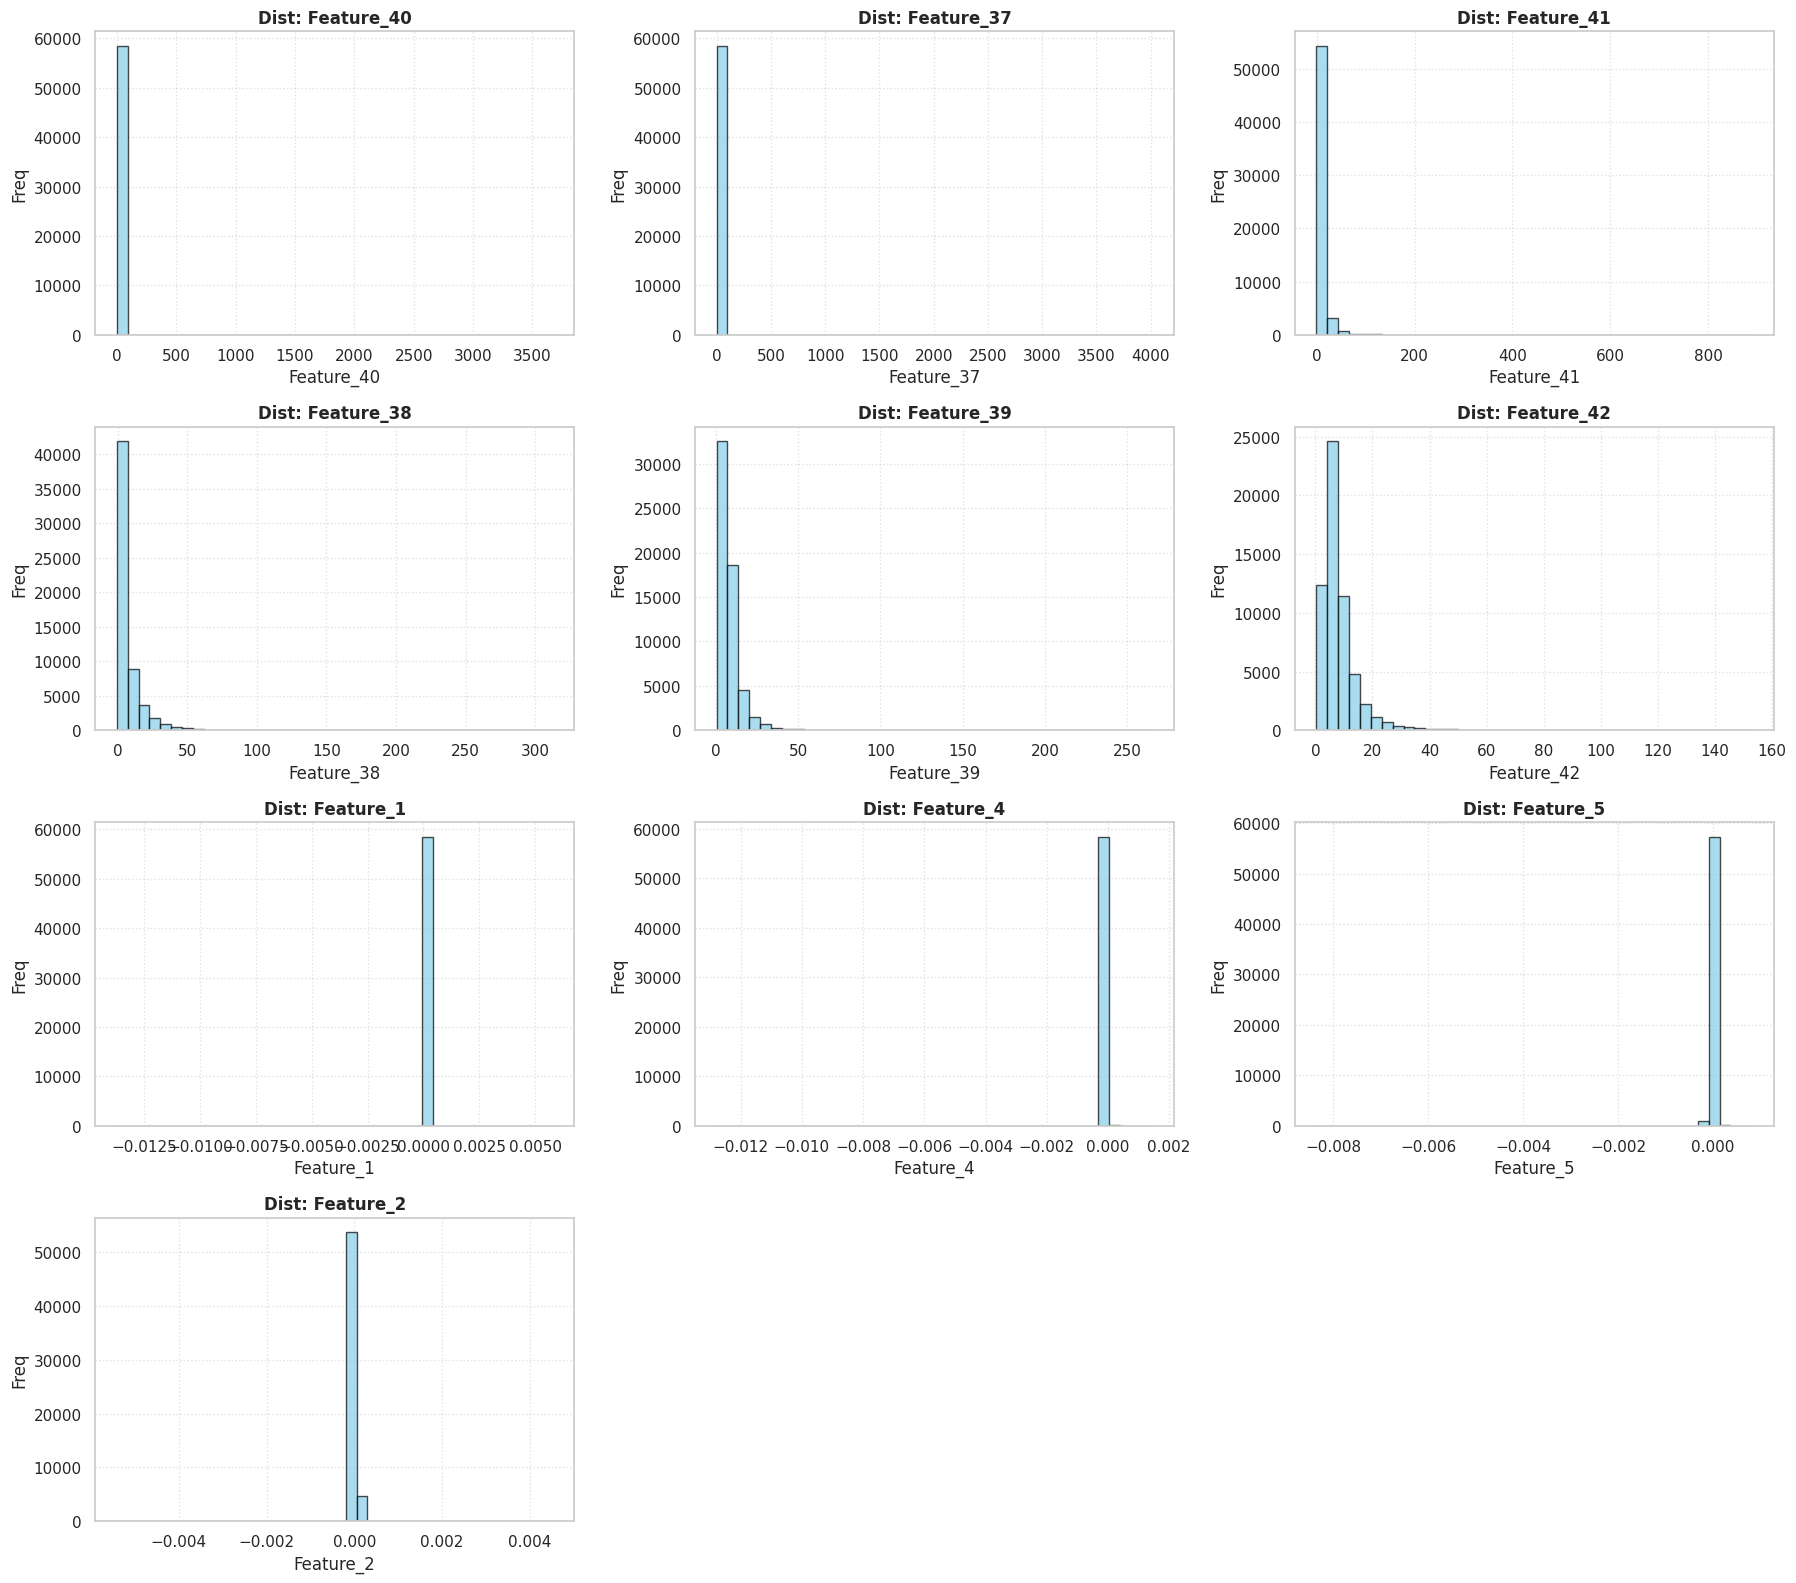

In [79]:
import math

# 3. Histograms for Selected Features (Grid Layout)
# Visualizing the raw frequency distribution of our 10 selected features.
n_cols = 3
n_rows = math.ceil(len(selected_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    axes[i].hist(df[col], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f"Dist: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Freq")
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Removing empty subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

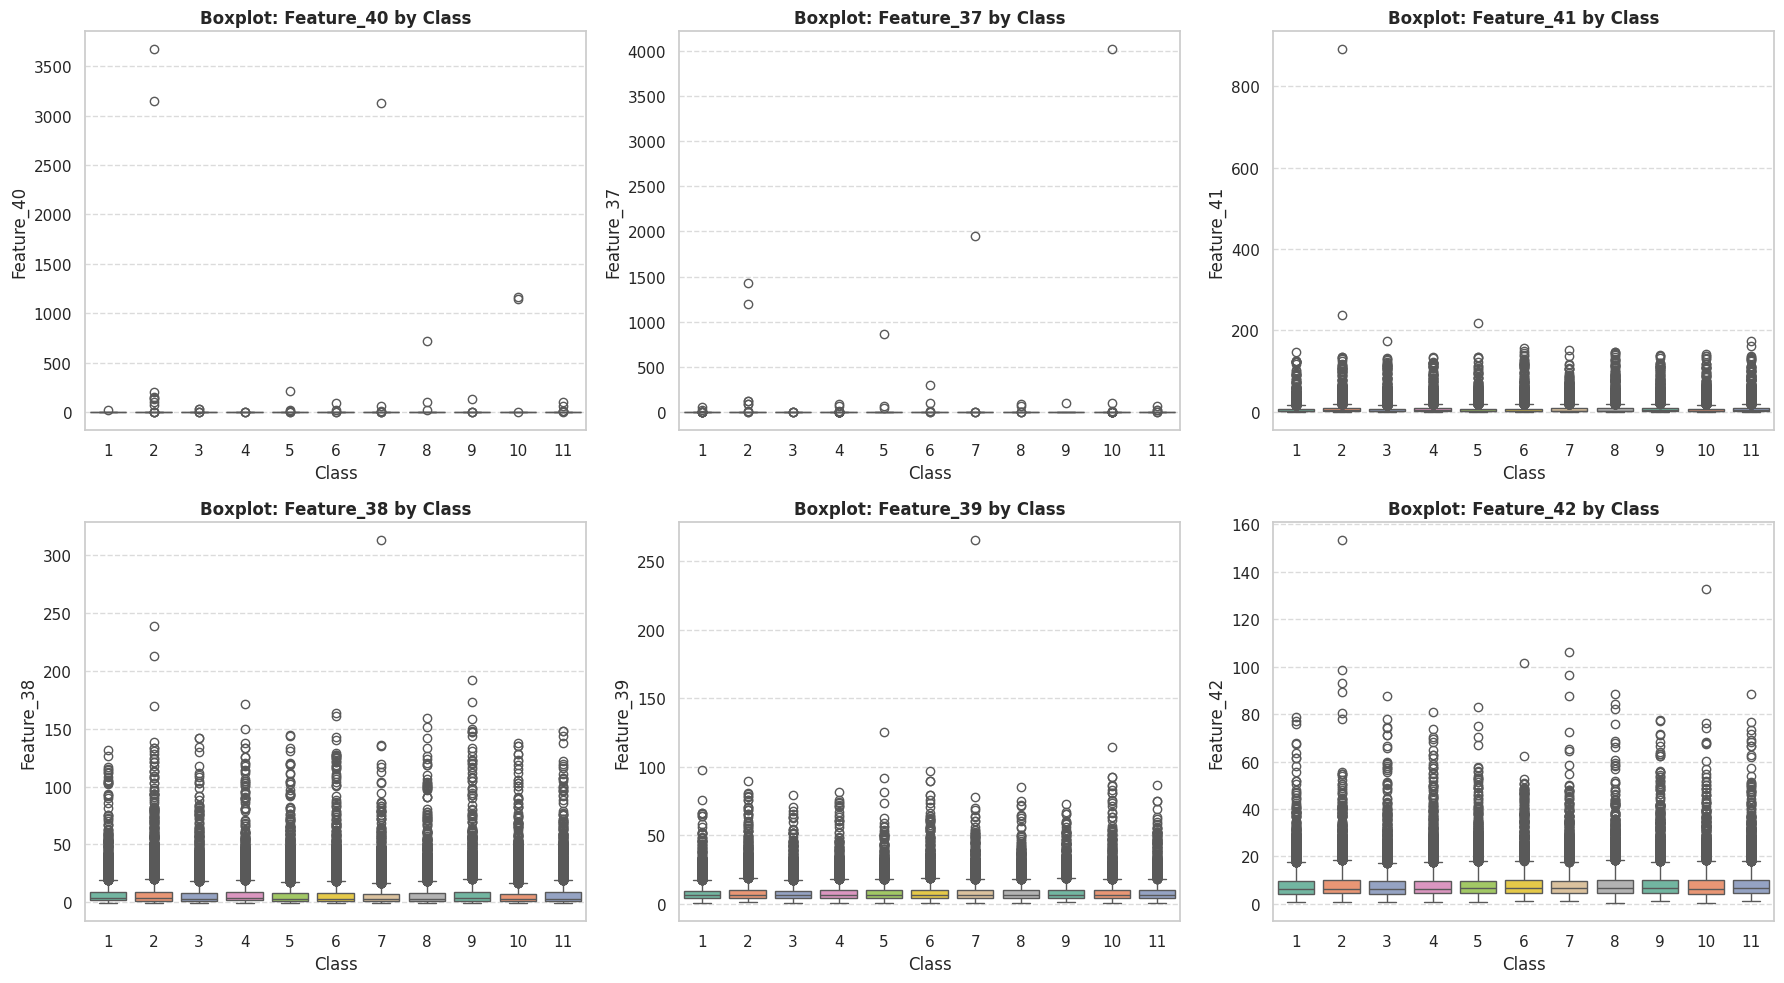

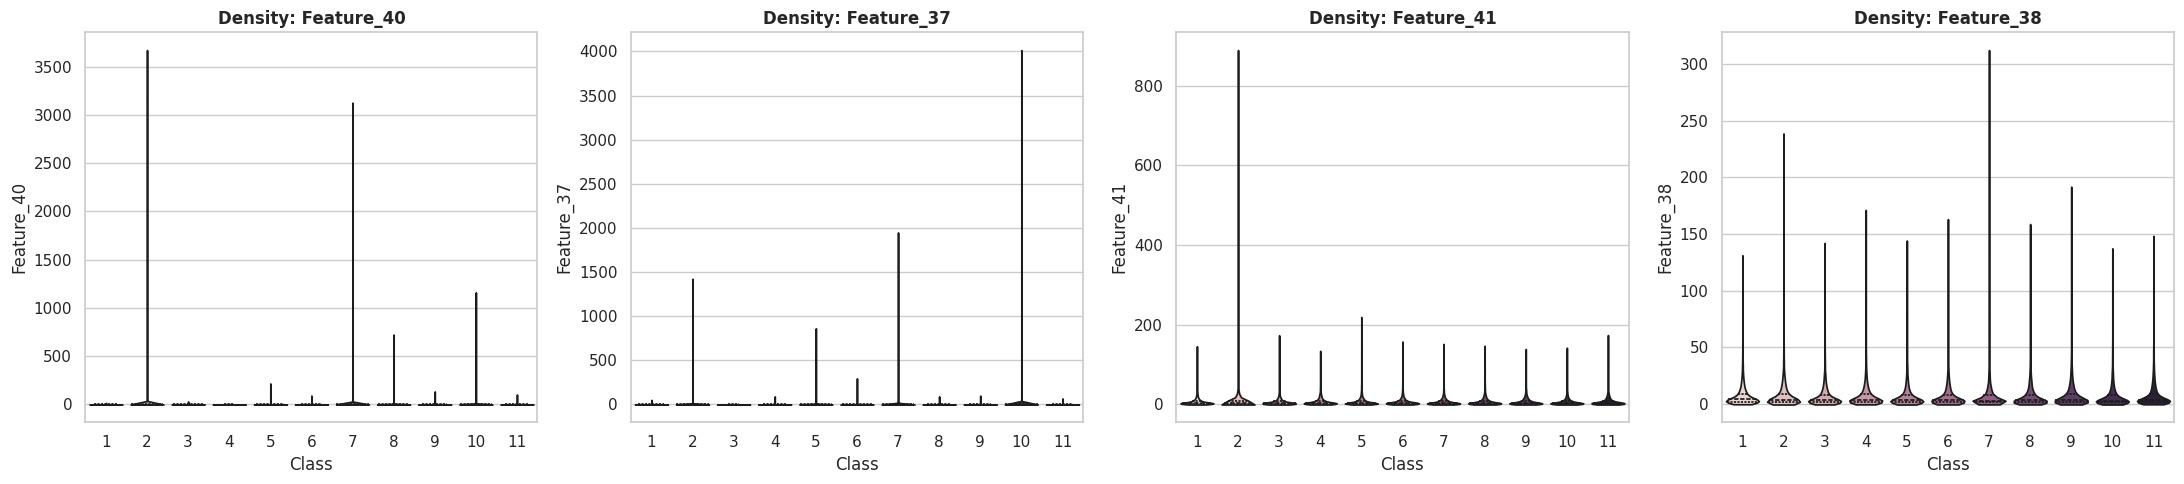


Summary table for selected features:


,mean,std,min,max,variance,skewness
Feature_40,-0.397753,25.018942,-0.902350,3670.800000,625.947447,125.395331
Feature_37,-0.463273,20.396029,-0.912300,4015.400000,415.997997,156.035148
Feature_41,7.293855,12.451875,-0.596830,889.930000,155.049192,10.443480
Feature_38,7.447239,12.240863,-0.618020,312.520000,149.838732,5.092873
Feature_39,8.406806,6.897353,0.522180,265.330000,47.573479,4.523642
Feature_42,8.273775,6.566008,0.320660,153.150000,43.112463,3.821186
Feature_1,-0.000003,0.000072,-0.013721,0.005784,0.000000,-139.596224
Feature_4,-0.000001,0.000063,-0.012787,0.001453,0.000000,-175.777435
Feature_5,0.000001,0.000057,-0.008356,0.000825,0.000000,-62.548066
Feature_2,0.000001,0.000056,-0.005414,0.004525,0.000000,-12.209813



Range and Metrics of selected features:
Feature_40: min=-0.902350, max=3670.800000, std=25.018942, skew=125.3953
Feature_37: min=-0.912300, max=4015.400000, std=20.396029, skew=156.0351
Feature_41: min=-0.596830, max=889.930000, std=12.451875, skew=10.4435
Feature_38: min=-0.618020, max=312.520000, std=12.240863, skew=5.0929
Feature_39: min=0.522180, max=265.330000, std=6.897353, skew=4.5236
Feature_42: min=0.320660, max=153.150000, std=6.566008, skew=3.8212
Feature_1: min=-0.013721, max=0.005784, std=0.000072, skew=-139.5962
Feature_4: min=-0.012787, max=0.001453, std=0.000063, skew=-175.7774
Feature_5: min=-0.008356, max=0.000825, std=0.000057, skew=-62.5481
Feature_2: min=-0.005414, max=0.004525, std=0.000056, skew=-12.2098


In [80]:
# 4. Boxplots by Class
n_cols_box = 3
n_rows_box = math.ceil(len(top_var_features) / n_cols_box)

fig, axes = plt.subplots(n_rows_box, n_cols_box, figsize=(18, n_rows_box * 5))
axes = axes.flatten()

for i, col in enumerate(top_var_features):
    # Boxplots showing the median and quartiles for each of the 11 classes.
    sns.boxplot(data=df, x="Class", y=col, ax=axes[i], palette="Set2", hue="Class", legend=False)
    axes[i].set_title(f"Boxplot: {col} by Class", fontsize=12, fontweight='bold')
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 5. Violin Plots for Top 4 Density Visualization
# Violin plots combine boxplots with kernel density estimation to show the "fatness" of the data.
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, col in enumerate(top_var_features[:4]):
    sns.violinplot(data=df, x="Class", y=col, inner="quartile", cut=0, ax=axes[i], hue="Class", legend=False)
    axes[i].set_title(f"Density: {col}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Final Summary
# Generating a heat-mapped table to highlight extreme skewness or variance numerically.
selected_summary = df[selected_features].describe().T[["mean", "std", "min", "max"]]
selected_summary["variance"] = df[selected_features].var()
selected_summary["skewness"] = df[selected_features].skew()

print("\nSummary table for selected features:")
display(selected_summary.style.background_gradient(subset=['skewness', 'variance'], cmap='YlOrRd'))

# 7. Simple interpretation helpers
print("\nRange and Metrics of selected features:")
for col in selected_features:
    print(f"{col}: min={df[col].min():.6f}, max={df[col].max():.6f}, std={df[col].std():.6f}, skew={df[col].skew():.4f}")

# Section 3 EDA: Part-2
This section explores the relationships between features and performs dimensionality reduction. It begins by computing a correlation matrix and visualizing it with a heatmap to identify highly correlated features. Scatter plots of the strongest feature pairs are then generated to observe how well they separate the target classes. Finally, Principal Component Analysis (PCA) is applied to project the high-dimensional data into a 2D space, visualizing the overall separability of the classes and identifying the specific features that drive the most variance in the dataset.

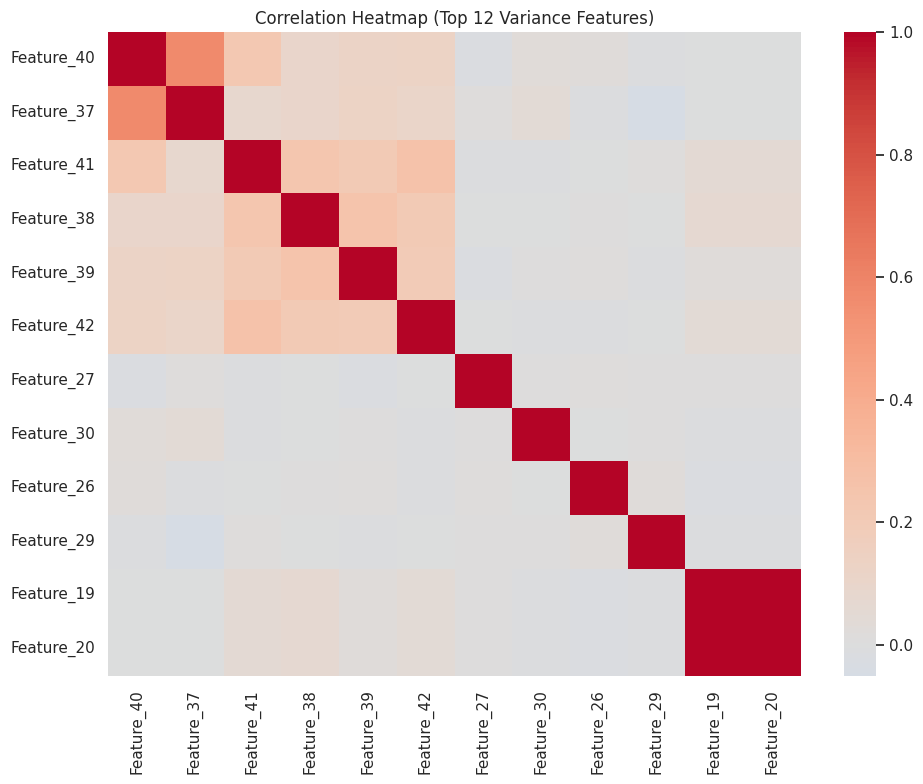

Top 15 strongest feature correlation pairs:


,Feature_A,Feature_B,Abs_Correlation
0,Feature_23,Feature_22,1.000000
1,Feature_19,Feature_20,1.000000
2,Feature_11,Feature_10,1.000000
3,Feature_23,Feature_24,1.000000
4,Feature_20,Feature_21,1.000000
5,Feature_24,Feature_22,1.000000
6,Feature_19,Feature_21,0.999999
7,Feature_8,Feature_7,0.999999
8,Feature_11,Feature_12,0.999994
9,Feature_10,Feature_12,0.999993


In [81]:
feature_cols = [f"Feature_{i}" for i in range(1, 49)]

# 1. Correlation matrix for all features
# Computes the Pearson correlation coefficient between every pair of features.
corr_matrix = df[feature_cols].corr()

# 2. Heatmap for a smaller, clearer subset:
#focusing on the top 12 highest-variance features.
top12_var_features = variance_series.head(12).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top12_var_features].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Top 12 Variance Features)")
plt.tight_layout()
plt.show()

# 3. Strongest absolute correlation pairs across all 48 features
# Flattening the matrix to easily sort and find the absolute highest correlations.
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs = corr_pairs.sort_values(ascending=False)

# Removing duplicate pairs (e.g., Feature_1 vs Feature_2 is the same as Feature_2 vs Feature_1)
seen = set()
unique_pairs = []
for (f1, f2), val in corr_pairs.items():
    key = tuple(sorted([f1, f2]))
    if key not in seen:
        seen.add(key)
        unique_pairs.append((f1, f2, val))
    if len(unique_pairs) == 15: # Grab the top 15 strongest relationships
        break

strong_corr_df = pd.DataFrame(unique_pairs, columns=["Feature_A", "Feature_B", "Abs_Correlation"])

print("Top 15 strongest feature correlation pairs:")
display(strong_corr_df)

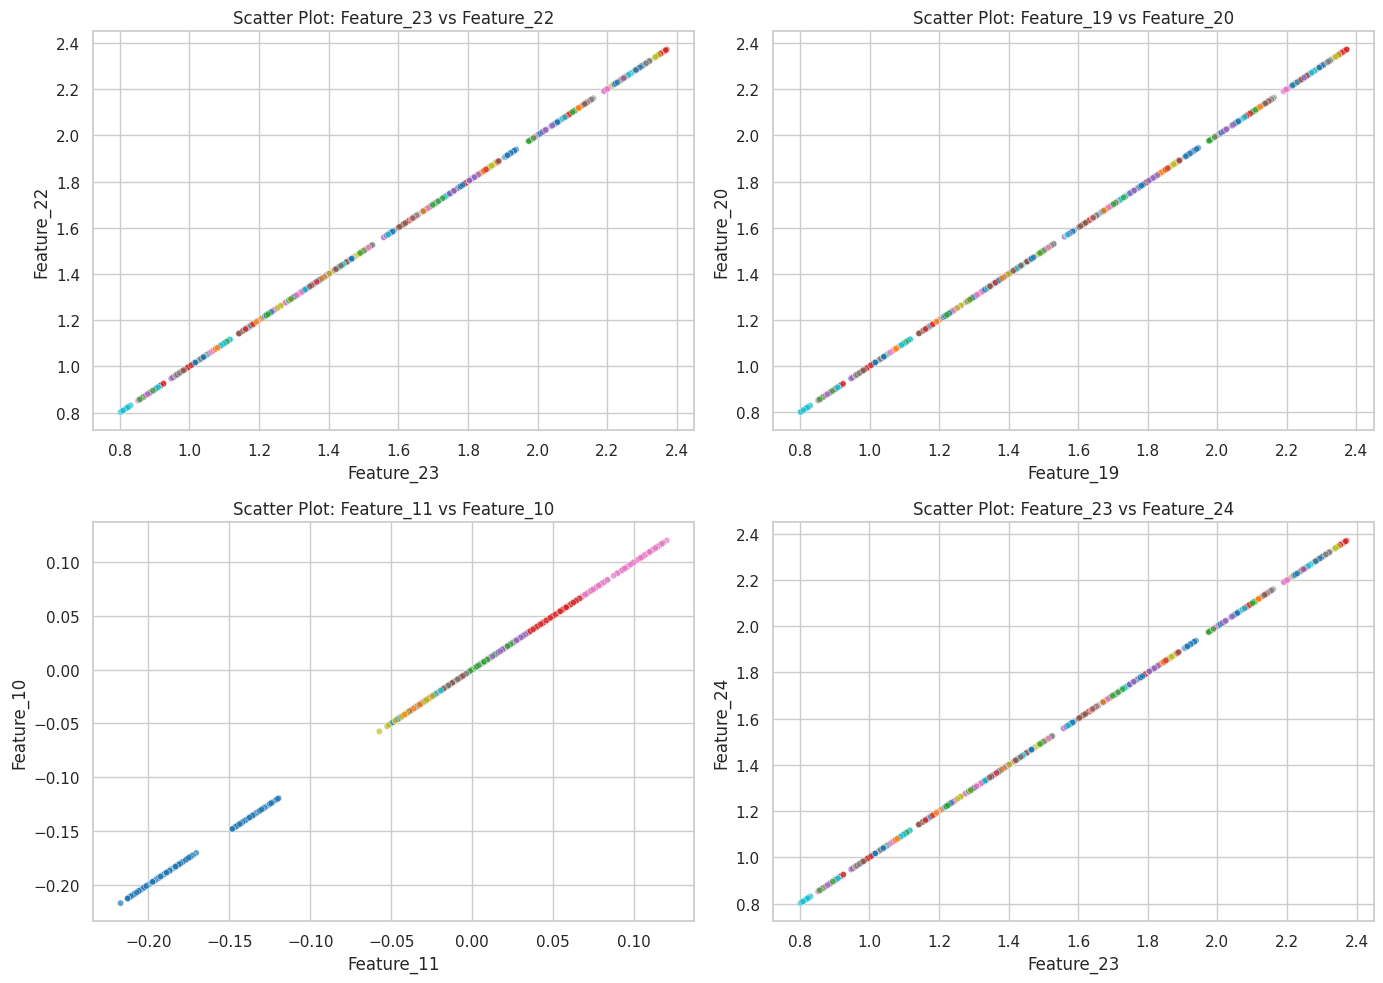

In [82]:
# 4. Scatter plots for top 4 strongest pairs
# Extracting the names of the top 4 highly correlated feature pairs.
top_scatter_pairs = strong_corr_df.head(4)[["Feature_A", "Feature_B"]].values.tolist()

# Sampling the data for faster plotting and to avoid overplotting.
scatter_sample = df.sample(n=min(3000, len(df)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (f1, f2) in enumerate(top_scatter_pairs):
    # Plotting the pairs against each other, color-coded by the motor's operating Class.
    sns.scatterplot(data=scatter_sample, x=f1, y=f2, hue="Class", palette="tab10", s=20, alpha=0.7, legend=False, ax=axes[i])
    axes[i].set_title(f"Scatter Plot: {f1} vs {f2}")

plt.tight_layout()
plt.show()

Explained variance ratio:
PC1: 0.1877
PC2: 0.1366
Total (PC1 + PC2): 0.3243


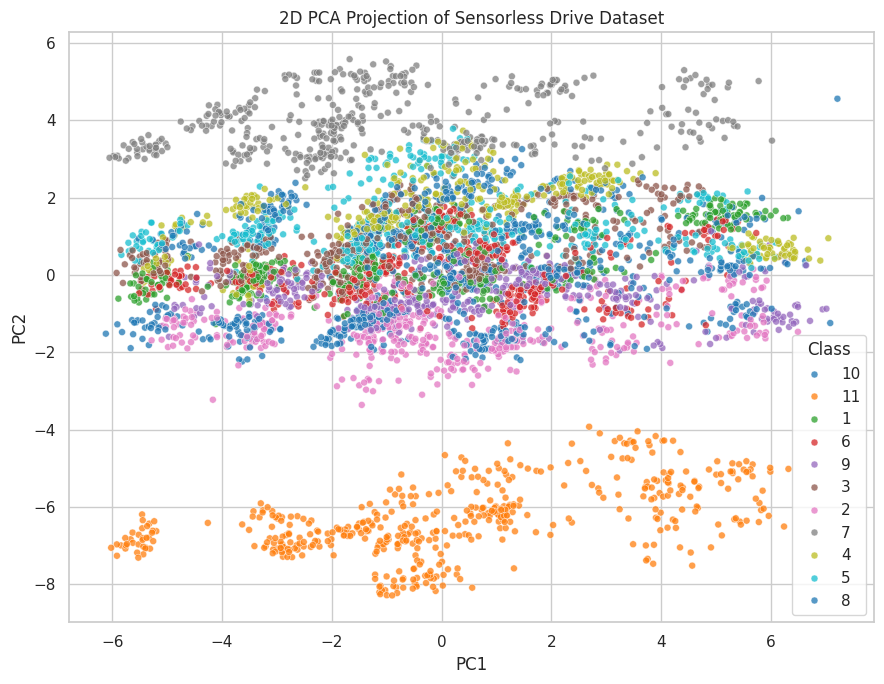


Top 10 absolute loadings for PC1:


,Abs_PC1_Loading
Feature_22,0.275742
Feature_23,0.275735
Feature_24,0.275628
Feature_19,0.275077
Feature_20,0.275069
Feature_21,0.274960
Feature_14,0.273655
Feature_17,0.267845
Feature_18,0.259004
Feature_16,0.254833



Top 10 absolute loadings for PC2:


,Abs_PC2_Loading
Feature_10,0.361459
Feature_12,0.361457
Feature_11,0.361451
Feature_7,0.344505
Feature_8,0.344469
Feature_9,0.344343
Feature_35,0.267391
Feature_36,0.267307
Feature_34,0.267286
Feature_45,0.085003


In [83]:
# 5. PCA on standardized full feature set
# PCA is highly sensitive to the scale of the data. so needs to be standardize first.
scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(df[feature_cols])

# Squashing the 48 dimensions down to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_eda)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": df["Class"].astype(str)
})

# How much of the original dataset's information (variance) was kept with just 2 dimensions?
print("Explained variance ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total (PC1 + PC2):", round(pca.explained_variance_ratio_.sum(), 4))

# 6. PCA scatter plot
pca_sample = pca_df.sample(n=min(5000, len(pca_df)), random_state=42)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_sample,
    x="PC1",
    y="PC2",
    hue="Class",
    palette="tab10",
    s=25,
    alpha=0.75
)
plt.title("2D PCA Projection of Sensorless Drive Dataset")
plt.tight_layout()
plt.show()

# 7. Top PCA loadings
# "Loadings" tells which of the original 48 features contributed the most to PC1 and PC2.
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1_Loading", "PC2_Loading"]
)

pc1_top = loadings["PC1_Loading"].abs().sort_values(ascending=False).head(10)
pc2_top = loadings["PC2_Loading"].abs().sort_values(ascending=False).head(10)

print("\nTop 10 absolute loadings for PC1:")
display(pc1_top.to_frame("Abs_PC1_Loading"))

print("\nTop 10 absolute loadings for PC2:")
display(pc2_top.to_frame("Abs_PC2_Loading"))

# Analysis for Section 3

In this section, I performed exploratory data analysis to better understand the distribution of the features and the relationships between them. I began by selecting the highest-variance and lowest-variance features so that I could compare variables with very different levels of spread. Using skewness values, histograms, boxplots, violin plots, and summary statistics, I examined how these selected features were distributed and how they behaved across the target classes. The results showed that many features were highly skewed, several contained extreme outliers, and the class distributions for individual features overlapped considerably. This suggests that single features alone are unlikely to separate all classes clearly, meaning the classification problem is not simple.

I then explored relationships between features by calculating correlations, visualising them in a heatmap, and plotting the strongest correlated feature pairs. This revealed that several features were extremely highly correlated, indicating that some variables may contain overlapping or redundant information. At last, I applied PCA after standardising the features to reduce the data into two principal components and visualise the overall class structure. The PCA results showed some visible grouping between classes, but also substantial overlap, meaning the dataset contains structure but is not perfectly separable in low dimensions.



# Section 4: Preprocessing Pipeline

This section prepares the dataset for machine learning model training. It isolates the features and the target variable, encoding the target classes to a zero-based index (0-10) required by neural networks.Then performs a stratified split to divide the data into training (70%), validation (15%), and testing (15%) sets, ensuring each subset maintains the original class distribution. Finally, it standardizes the feature values using the training set's statistics (to prevent data leakage) and casts the arrays to `float32` for optimal TensorFlow performance.

In [84]:
feature_cols = [f"Feature_{i}" for i in range(1, 49)]

# 1. Define X and y
# Extracting features (X) and target (y) into separate variables for modeling.
X = df[feature_cols].copy()
y = df["Class"].astype(int).copy()

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
print("Original classes:", sorted(y.unique()))

# 2. Encode labels from 1-11 to 0-10
# Many ML frameworks expect class labels to be 0-indexed.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nEncoded class mapping:")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"Original class {original} -> Encoded class {encoded}")

# 3. Stratified split: 70% train, 15% val, 15% test
# Stratify=y_encoded ensures the 11 classes maintain their original ratios in all 3 splits.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Splitting the temporary 30% evenly into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

Original X shape: (58508, 48)
Original y shape: (58508,)
Original classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Encoded class mapping:
Original class 1 -> Encoded class 0
Original class 2 -> Encoded class 1
Original class 3 -> Encoded class 2
Original class 4 -> Encoded class 3
Original class 5 -> Encoded class 4
Original class 6 -> Encoded class 5
Original class 7 -> Encoded class 6
Original class 8 -> Encoded class 7
Original class 9 -> Encoded class 8
Original class 10 -> Encoded class 9
Original class 11 -> Encoded class 10

Split shapes:
X_train: (40955, 48) y_train: (40955,)
X_val:   (8776, 48) y_val:   (8776,)
X_test:  (8777, 48) y_test:  (8777,)


In [85]:
# 4. Check class distributions in each split
# Defining a helper function to verify that our stratification was successful.
def class_dist(y_array, name):
    vals, counts = np.unique(y_array, return_counts=True)
    pct = counts / counts.sum() * 100
    out = pd.DataFrame({
        "Encoded_Class": vals,
        "Count": counts,
        "Percentage": np.round(pct, 4)
    })
    print(f"\n{name} class distribution:")
    display(out)
    return out

train_dist = class_dist(y_train, "Train")
val_dist   = class_dist(y_val, "Validation")
test_dist  = class_dist(y_test, "Test")


Train class distribution:


,Encoded_Class,Count,Percentage
0,0,3723,9.0905
1,1,3723,9.0905
2,2,3724,9.0929
3,3,3723,9.0905
4,4,3723,9.0905
5,5,3723,9.0905
6,6,3723,9.0905
7,7,3723,9.0905
8,8,3723,9.0905
9,9,3724,9.0929



Validation class distribution:


,Encoded_Class,Count,Percentage
0,0,798,9.0930
1,1,798,9.0930
2,2,797,9.0816
3,3,798,9.0930
4,4,798,9.0930
5,5,798,9.0930
6,6,798,9.0930
7,7,798,9.0930
8,8,798,9.0930
9,9,797,9.0816



Test class distribution:


,Encoded_Class,Count,Percentage
0,0,797,9.0806
1,1,798,9.0919
2,2,798,9.0919
3,3,798,9.0919
4,4,798,9.0919
5,5,798,9.0919
6,6,798,9.0919
7,7,798,9.0919
8,8,798,9.0919
9,9,798,9.0919


In [86]:
# 5. Standardize features using TRAIN only
# Fitting the scaler ONLY on X_train prevents information from the val/test sets from leaking into the training process.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert to float32 for TensorFlow efficiency
# Deep learning models train faster and use less memory with 32-bit floats.
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled   = X_val_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)

# 6. Sanity checks on scaled data
# Verifying that standardization worked (mean should be approx 0, std should be approx 1).
train_means = X_train_scaled.mean(axis=0)
train_stds = X_train_scaled.std(axis=0)

print("\nScaled training feature mean (first 10):")
print(np.round(train_means[:10], 4))

print("\nScaled training feature std (first 10):")
print(np.round(train_stds[:10], 4))

print("\nOverall scaled train mean:", round(float(X_train_scaled.mean()), 4))
print("Overall scaled train std:", round(float(X_train_scaled.std()), 4))

# 7. Final metadata for modelling
# Extracting dimensions to pass into the input layer of the model later.
input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

print("\nModel-ready metadata:")
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

# 8. Assertions
# Final hard checks to ensure no data was dropped or shaped incorrectly during preprocessing.
assert X_train_scaled.shape[1] == 48, "Input feature count is not 48."
assert num_classes == 11, "Unexpected number of classes."
assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == len(df), "Split sizes do not add up."



Scaled training feature mean (first 10):
[-0. -0.  0.  0. -0. -0. -0. -0.  0. -0.]

Scaled training feature std (first 10):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Overall scaled train mean: -0.0
Overall scaled train std: 1.0

Model-ready metadata:
Input dimension: 48
Number of classes: 11


# Section 4: Analysis
In this section, preparation of dataset was done before machine learning .First, I separated the 48 input features into X and the target class into y. Then I used label encoding to convert the original class labels from 1–11 into a zero-based range of 0–10. I then split the dataset into training, validation, and test sets using a stratified approach, with 70% of the data allocated to training and the remaining 30% divided equally between validation and test sets. Stratification was used so that each subset would preserve the original class distribution, ensuring fair and reliable evaluation later in the project. The class distribution tables confirmed that the split was successful, as each subset retained an almost identical percentage for all 11 classes.

After splitting the data, I standardised the feature values using StandardScaler, fitting the scaler only on the training data and then applying the same transformation to the validation and test sets. This was done to prevent data leakage and to ensure that all features were placed on a comparable scale, which is especially important for neural networks because they are sensitive to differences in feature magnitude. I then converted the scaled arrays to float32. Finally, I performed sanity checks to verify that the scaled training data had mean values close to 0 and standard deviations close to 1.

# Section 5: Model 1 Single Layer Perceptron (SLP) Baseline

This section establishes a performance baseline using a simple Single Layer Perceptron (SLP). The model is trained with early stopping to prevent overfitting, and its learning process is visualized through loss and accuracy curves.Then the model's predictive capabilities are evaluated on both the validation and test sets using metrics such as Accuracy, F1-score, Precision, and Recall. A confusion matrix and classification report are also generated to assess class-level performance, and the final results are stored for later comparison with more complex architectures.

In [87]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# 1. Building SLP baseline
slp_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(num_classes, activation="softmax")
])

# Compiling the model with Adam optimizer.
slp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SLP model summary:")
slp_model.summary()

# 2.Early stopping prevents overfitting by halting training if the validation loss stops improving.
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# 3. Training the model
# Fitting the model using the scaled training data and validating on the val set.
history_slp = slp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=40,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

SLP model summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539 (2.11 KB)

 Trainable params: 539 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3257 - loss: 2.0825 - val_accuracy: 0.5011 - val_loss: 1.6472
Epoch 2/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5626 - loss: 1.4838 - val_accuracy: 0.6054 - val_loss: 1.3347
Epoch 3/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6367 - loss: 1.2546 - val_accuracy: 0.6640 - val_loss: 1.1638
Epoch 4/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6845 - loss: 1.1146 - val_accuracy: 0.7019 - val_loss: 1.0482
Epoch 5/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7151 - loss: 1.0141 - val_accuracy: 0.7322 - val_loss: 0.9620
Epoch 6/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7396 - loss: 0.9365 - val_accuracy: 0.7554 - val_loss: 0.8932
Epoch 7/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7612 - loss: 0.8738 - val_accuracy: 0.7716 - val_loss: 0.8366
Epoch 8/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7789 - loss: 0.8206 - val_accuracy: 0.

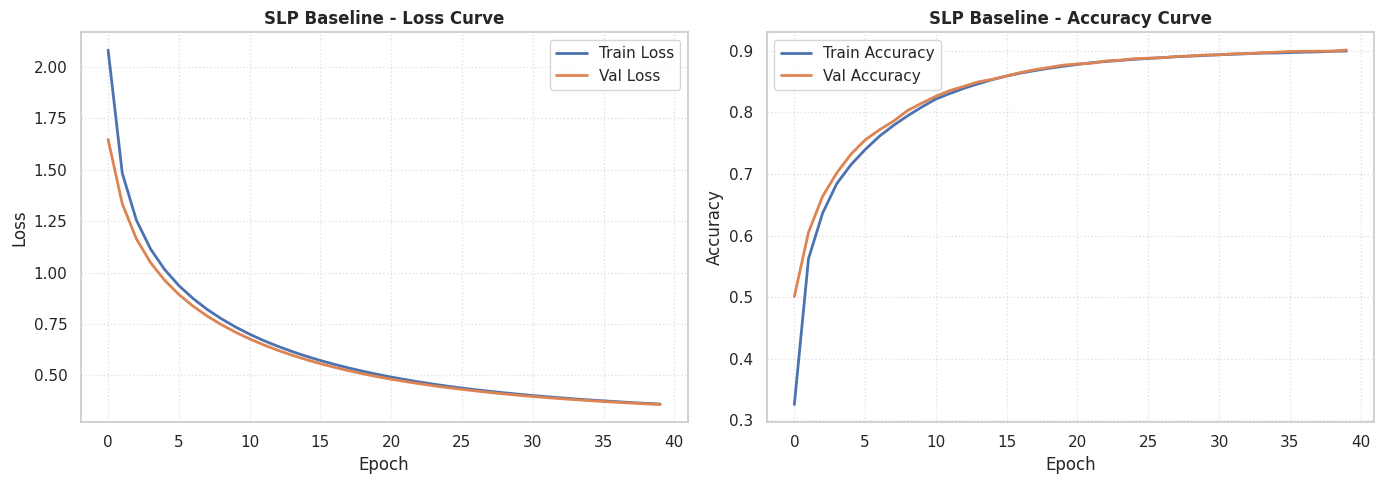

In [88]:
# 4. Plotting training curves
history_df = pd.DataFrame(history_slp.history)

# side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
axes[0].plot(history_df["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history_df["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("SLP Baseline - Loss Curve", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Accuracy Curve
axes[1].plot(history_df["accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history_df["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].set_title("SLP Baseline - Accuracy Curve", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


Validation performance:
Validation Accuracy: 0.9013
Validation Macro F1: 0.9006

Test performance:
Test Accuracy: 0.896
Test Macro F1: 0.895
Test Weighted F1: 0.895
Test Macro Precision: 0.8955
Test Macro Recall: 0.896

SLP Classification Report:


,precision,recall,f1-score,support
1,0.925700,0.953576,0.939431,797.000000
2,0.880099,0.892231,0.886123,798.000000
3,0.910520,0.943609,0.926769,798.000000
4,0.913750,0.916040,0.914894,798.000000
5,0.854412,0.728070,0.786198,798.000000
6,0.810983,0.795739,0.803289,798.000000
7,0.983891,0.994987,0.989408,798.000000
8,0.835227,0.921053,0.876043,798.000000
9,0.840764,0.827068,0.833860,798.000000
10,0.896947,0.883459,0.890152,798.000000


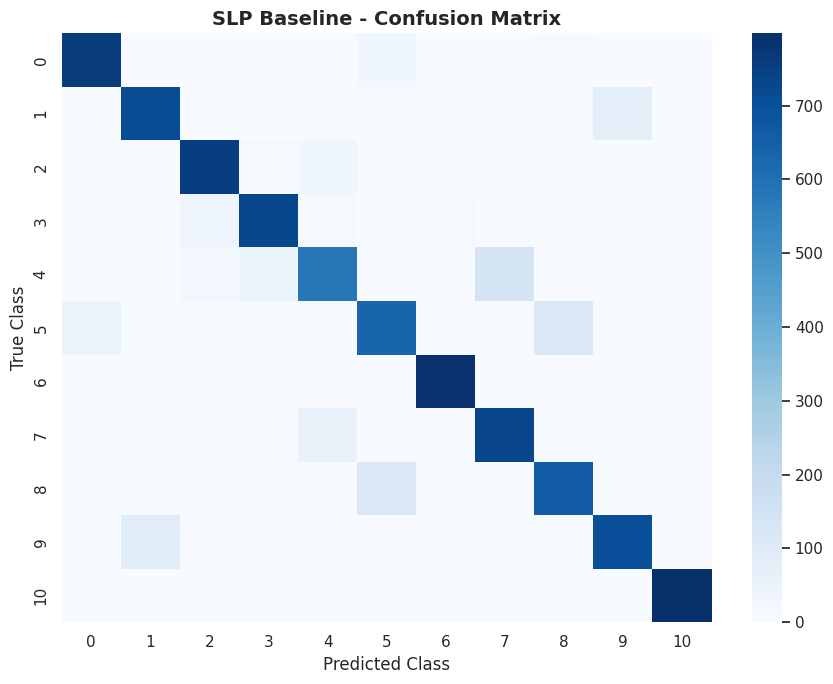


Stored baseline results:
{'val_accuracy': 0.9013217866909754, 'val_macro_f1': 0.9006058829005537, 'test_accuracy': 0.8959781246439558, 'test_macro_f1': 0.8950491078454945, 'test_weighted_f1': 0.8950440511873036, 'test_macro_precision': 0.8955492659064217, 'test_macro_recall': 0.8959846862508158, 'epochs_ran': 40}


In [89]:
# 5. Validation predictions
# Checking performance on the validation set before finalizing with the test set.
y_val_proba_slp = slp_model.predict(X_val_scaled, verbose=0)
y_val_pred_slp = np.argmax(y_val_proba_slp, axis=1)

val_acc_slp = accuracy_score(y_val, y_val_pred_slp)
val_macro_f1_slp = f1_score(y_val, y_val_pred_slp, average="macro")

print("\nValidation performance:")
print("Validation Accuracy:", round(val_acc_slp, 4))
print("Validation Macro F1:", round(val_macro_f1_slp, 4))

# 6. Test predictions
# Final evaluation
y_test_proba_slp = slp_model.predict(X_test_scaled, verbose=0)
y_test_pred_slp = np.argmax(y_test_proba_slp, axis=1)

test_acc_slp = accuracy_score(y_test, y_test_pred_slp)
test_macro_f1_slp = f1_score(y_test, y_test_pred_slp, average="macro")
test_weighted_f1_slp = f1_score(y_test, y_test_pred_slp, average="weighted")
test_precision_slp = precision_score(y_test, y_test_pred_slp, average="macro")
test_recall_slp = recall_score(y_test, y_test_pred_slp, average="macro")

print("\nTest performance:")
print("Test Accuracy:", round(test_acc_slp, 4))
print("Test Macro F1:", round(test_macro_f1_slp, 4))
print("Test Weighted F1:", round(test_weighted_f1_slp, 4))
print("Test Macro Precision:", round(test_precision_slp, 4))
print("Test Macro Recall:", round(test_recall_slp, 4))

# 7. Classification report
class_names = [str(c) for c in label_encoder.classes_]

slp_report = classification_report(
    y_test,
    y_test_pred_slp,
    target_names=class_names,
    output_dict=True
)

slp_report_df = pd.DataFrame(slp_report).T
print("\nSLP Classification Report:")
display(slp_report_df)

# 8. Confusion matrix
# Visualizing exactly where the model is making misclassifications.
cm_slp = confusion_matrix(y_test, y_test_pred_slp)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_slp, annot=False, cmap="Blues", fmt="d") # Kept annot=False per your original code
plt.title("SLP Baseline - Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.tight_layout()
plt.show()

# 9. Save key results for comparison
results_summary = {}

results_summary["SLP_Baseline"] = {
    "val_accuracy": float(val_acc_slp),
    "val_macro_f1": float(val_macro_f1_slp),
    "test_accuracy": float(test_acc_slp),
    "test_macro_f1": float(test_macro_f1_slp),
    "test_weighted_f1": float(test_weighted_f1_slp),
    "test_macro_precision": float(test_precision_slp),
    "test_macro_recall": float(test_recall_slp),
    "epochs_ran": len(history_df)
}

print("\nStored baseline results:")
print(results_summary["SLP_Baseline"])


# Section 5: Analysis
In this section development of first predictive model was done, using a Single-Layer Perceptron (SLP) as a baseline. The purpose of this model was to provide a simple neural network benchmark that could be used to assess how well the dataset could be classified using only a linear decision layer. The model consisted of a single dense output layer with softmax activation, making it suitable for the 11-class classification problem. I trained the model using the Adam optimiser and sparse categorical cross-entropy loss, while monitoring validation loss with early stopping to reduce the risk of unnecessary training. To evaluate the learning behaviour of the model, I plotted both the loss curves and accuracy curves for the training and validation sets across epochs.

The results showed that the SLP performed strongly as a baseline model, achieving approximately 90.1% validation accuracy and 89.6% test accuracy, with a test macro F1-score of around 0.895. The training and validation curves improved smoothly and remained close to each other, suggesting stable learning and no clear signs of overfitting. The confusion matrix showed a strong diagonal pattern, meaning that most classes were predicted correctly, although some classes such as 5, 6, 8, and 9 were more difficult than others. The classification report confirmed this, with some classes achieving near-perfect performance while others showed lower recall and F1-scores.

# Section 6: Model 2 Multi-Layer Perceptron (MLP)

This section introduces a more complex neural network architecture by adding a hidden layer with ReLU activation and a dropout layer for regularization. The model is trained, its loss and accuracy curves are visualized, and it is evaluated using the same robust metrics as the baseline.

In [90]:
# 1. Building MLP
# Adding a hidden layer (128 units) with ReLU activation to capture non-linear patterns.
# Dropout(0.20) acts as regularization to reduce overfitting on the training data.
basic_mlp = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(num_classes, activation="softmax")
])

basic_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("MLP summary:")
basic_mlp.summary()

# 2. Callbacks
# Halting training if the validation loss doesn't improve for 6 consecutive epochs.
early_stop_mlp = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

# 3. Train
# Training the neural network. Notice how quickly it converges compared to the SLP.
history_basic = basic_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop_mlp],
    verbose=1
)

MLP summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,691 (30.04 KB)

 Trainable params: 7,691 (30.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5648 - loss: 1.3167 - val_accuracy: 0.8062 - val_loss: 0.6782
Epoch 2/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8178 - loss: 0.5642 - val_accuracy: 0.8990 - val_loss: 0.3736
Epoch 3/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8772 - loss: 0.3755 - val_accuracy: 0.9282 - val_loss: 0.2642
Epoch 4/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9083 - loss: 0.2834 - val_accuracy: 0.9431 - val_loss: 0.2114
Epoch 5/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9253 - loss: 0.2349 - val_accuracy: 0.9524 - val_loss: 0.1793
Epoch 6/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9351 - loss: 0.2024 - val_accuracy: 0.9584 - val_loss: 0.1584
Epoch 7/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9424 - loss: 0.1805 - val_accuracy: 0.9635 - val_loss: 0.1435
Epoch 8/50
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9487 - loss: 0.1623 - val_accuracy: 0.

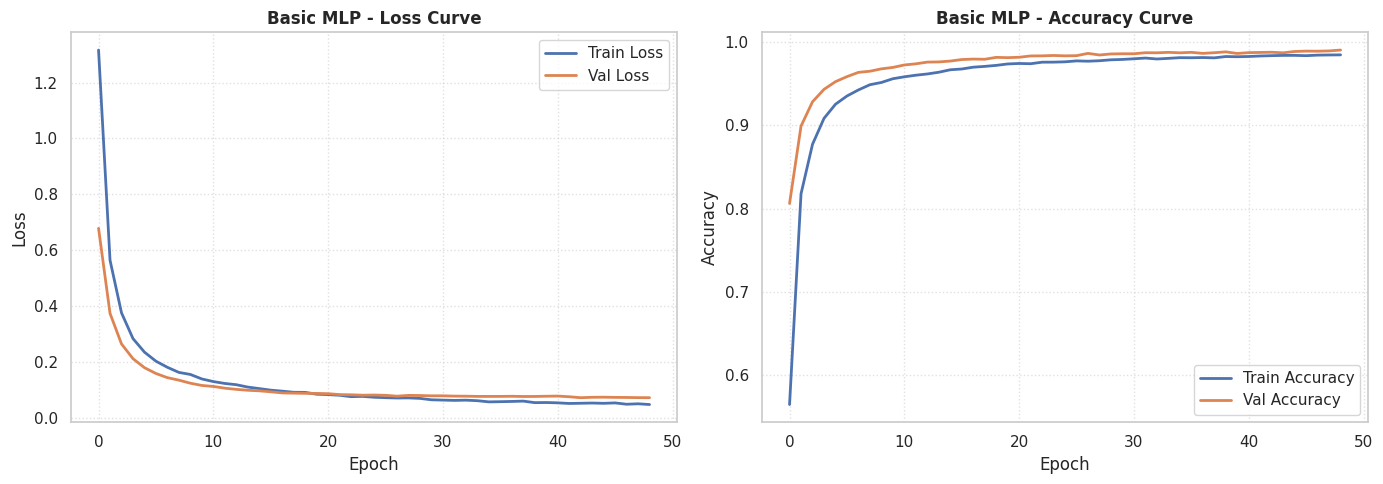

In [91]:
# 4. Plotting training curves
history_basic_df = pd.DataFrame(history_basic.history)

# side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
axes[0].plot(history_basic_df["loss"], label="Train Loss", linewidth=2)
axes[0].plot(history_basic_df["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_title("Basic MLP - Loss Curve", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Accuracy Curve
axes[1].plot(history_basic_df["accuracy"], label="Train Accuracy", linewidth=2)
axes[1].plot(history_basic_df["val_accuracy"], label="Val Accuracy", linewidth=2)
axes[1].set_title("Basic MLP - Accuracy Curve", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


Validation performance:
Validation Accuracy: 0.9877
Validation Macro F1: 0.9877

Test performance:
Test Accuracy: 0.9867
Test Macro F1: 0.9867
Test Weighted F1: 0.9867
Test Macro Precision: 0.9867
Test Macro Recall: 0.9867

Basic MLP Classification Report:


,precision,recall,f1-score,support
1,0.993726,0.993726,0.993726,797.00000
2,0.966584,0.978697,0.972603,798.00000
3,0.997478,0.991228,0.994343,798.00000
4,0.997491,0.996241,0.996865,798.00000
5,0.981084,0.974937,0.978001,798.00000
6,0.982346,0.976190,0.979258,798.00000
7,0.998748,1.000000,0.999374,798.00000
8,0.978960,0.991228,0.985056,798.00000
9,0.977584,0.983709,0.980637,798.00000
10,0.979695,0.967419,0.973518,798.00000


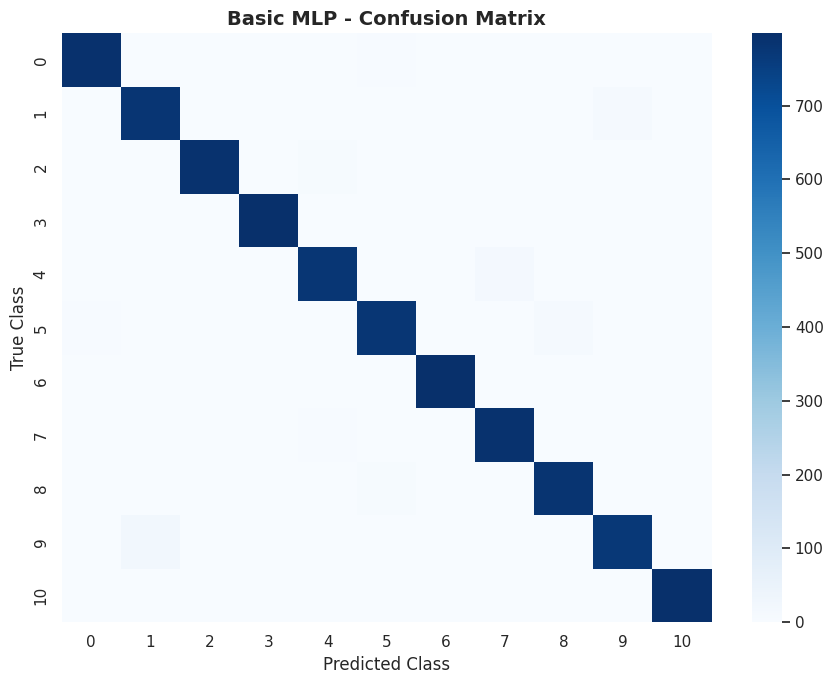


Stored Basic MLP results:
{'val_accuracy': 0.987693710118505, 'val_macro_f1': 0.9876838151339985, 'test_accuracy': 0.9866697049105617, 'test_macro_f1': 0.9866711305365282, 'test_weighted_f1': 0.9866703266919638, 'test_macro_precision': 0.9866997717956602, 'test_macro_recall': 0.9866705088259603, 'epochs_ran': 49}

Current comparison (SLP vs MLP):


,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_macro_precision,test_macro_recall,epochs_ran
SLP_Baseline,0.901322,0.900606,0.895978,0.895049,0.895044,0.895549,0.895985,40.0
MLP,0.987694,0.987684,0.986670,0.986671,0.986670,0.986700,0.986671,49.0


In [92]:
# 5. Validation predictions
y_val_proba_basic = basic_mlp.predict(X_val_scaled, verbose=0)
y_val_pred_basic = np.argmax(y_val_proba_basic, axis=1)

val_acc_basic = accuracy_score(y_val, y_val_pred_basic)
val_macro_f1_basic = f1_score(y_val, y_val_pred_basic, average="macro")

print("\nValidation performance:")
print("Validation Accuracy:", round(val_acc_basic, 4))
print("Validation Macro F1:", round(val_macro_f1_basic, 4))

# 6. Test predictions
y_test_proba_basic = basic_mlp.predict(X_test_scaled, verbose=0)
y_test_pred_basic = np.argmax(y_test_proba_basic, axis=1)

test_acc_basic = accuracy_score(y_test, y_test_pred_basic)
test_macro_f1_basic = f1_score(y_test, y_test_pred_basic, average="macro")
test_weighted_f1_basic = f1_score(y_test, y_test_pred_basic, average="weighted")
test_precision_basic = precision_score(y_test, y_test_pred_basic, average="macro")
test_recall_basic = recall_score(y_test, y_test_pred_basic, average="macro")

print("\nTest performance:")
print("Test Accuracy:", round(test_acc_basic, 4))
print("Test Macro F1:", round(test_macro_f1_basic, 4))
print("Test Weighted F1:", round(test_weighted_f1_basic, 4))
print("Test Macro Precision:", round(test_precision_basic, 4))
print("Test Macro Recall:", round(test_recall_basic, 4))

# 7. Classification report
basic_report = classification_report(
    y_test,
    y_test_pred_basic,
    target_names=class_names,
    output_dict=True
)

basic_report_df = pd.DataFrame(basic_report).T
print("\nBasic MLP Classification Report:")
display(basic_report_df)

# 8. Confusion matrix
cm_basic = confusion_matrix(y_test, y_test_pred_basic)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_basic, annot=False, cmap="Blues", fmt="d")
plt.title("Basic MLP - Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.tight_layout()
plt.show()

# 9. Storing results
results_summary["MLP"] = {
    "val_accuracy": float(val_acc_basic),
    "val_macro_f1": float(val_macro_f1_basic),
    "test_accuracy": float(test_acc_basic),
    "test_macro_f1": float(test_macro_f1_basic),
    "test_weighted_f1": float(test_weighted_f1_basic),
    "test_macro_precision": float(test_precision_basic),
    "test_macro_recall": float(test_recall_basic),
    "epochs_ran": len(history_basic_df)
}

print("\nStored Basic MLP results:")
print(results_summary["MLP"])

# 10.comparison vs SLP
comparison_now = pd.DataFrame({
    "SLP_Baseline": results_summary["SLP_Baseline"],
    "MLP": results_summary["MLP"]
}).T

print("\nCurrent comparison (SLP vs MLP):")
display(comparison_now)

# Section 6: Analysis
In this section, I developed Multi-Layer Perceptron (MLP) to improve upon the SLP baseline by allowing the model to learn more complex, non-linear patterns in the dataset. The model consisted of one hidden dense layer with 128 neurons and ReLU activation, followed by a dropout layer and a softmax output layer for the 11-class classification task. The hidden layer was introduced so that the network could capture feature interactions and non-linear decision boundaries that a simple SLP cannot learn. Dropout was included as a regularisation technique to reduce the risk of overfitting, while the model was trained using the Adam optimiser and sparse categorical cross-entropy loss.

The results showed that the MLP performed extremely well and delivered a major improvement over the SLP baseline. It achieved approximately 98.8% validation accuracy and 98.7% test accuracy, with a test macro F1-score of about 0.987. The learning curves showed fast and stable convergence, with training and validation performance remaining very close throughout training, which indicates strong generalisation and no signs of overfitting. The confusion matrix showed a very strong diagonal pattern, confirming that the model classified the vast majority of samples correctly. The classification report also demonstrated consistently high performance across all classes, with several classes achieving near-perfect precision, recall, and F1-scores.